In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
model_dir = "model" if os.path.exists("model") else os.path.join("..", "model")
vis_dir = "visualizations" if os.path.exists("visualizations") else os.path.join("..", "visualizations")
os.makedirs(model_dir, exist_ok=True)
os.makedirs(vis_dir, exist_ok=True)

In [3]:
def load_split(filename):
    paths = [
        filename,
        os.path.join("data", filename),
        os.path.join("..", "data", filename)
    ]
    for p in paths:
        if os.path.exists(p):
            return pd.read_csv(p)
    raise FileNotFoundError(f"Could not find '{filename}'! Make sure data files are uploaded.")

X_train = load_split("X_train.csv")
X_test = load_split("X_test.csv")
y_train = load_split("y_train.csv").values.ravel()
y_test = load_split("y_test.csv").values.ravel()

print(f"Loaded train/test splits successfully:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Loaded train/test splits successfully:
  X_train: (5285, 27), y_train: (5285,)
  X_test:  (1322, 27), y_test:  (1322,)


Train Models & Generate Comparison Table

In [4]:
# Initialize candidate algorithms
candidate_models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
}

comparison_records = []
trained_models = {}

for name, model in candidate_models.items():
    # Fit model on training split
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Generate predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate performance metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    comparison_records.append({
        "Model": name,
        "Train MAE": round(train_mae, 3),
        "Test MAE": round(test_mae, 3),
        "Train RMSE": round(train_rmse, 3),
        "Test RMSE": round(test_rmse, 3),
        "Train R²": round(train_r2, 4),
        "Test R²": round(test_r2, 4)
    })

comparison_df = pd.DataFrame(comparison_records)
print("=" * 80)
print("                     MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 80)
display(comparison_df)

                     MODEL PERFORMANCE COMPARISON TABLE


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Linear Regression (Baseline),0.498,0.452,2.083,1.804,0.7177,0.7697
1,Decision Tree Regressor,1.519,1.588,2.504,2.593,0.5921,0.5243
2,Random Forest Regressor,1.064,1.285,1.812,2.269,0.7864,0.6356


Comparative Performance Visualization

/tmp/ipykernel_1327/849007015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="Model", y="Test R²", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_1327/849007015.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x="Model", y="Test MAE", ax=axes[1], palette="Reds_d")


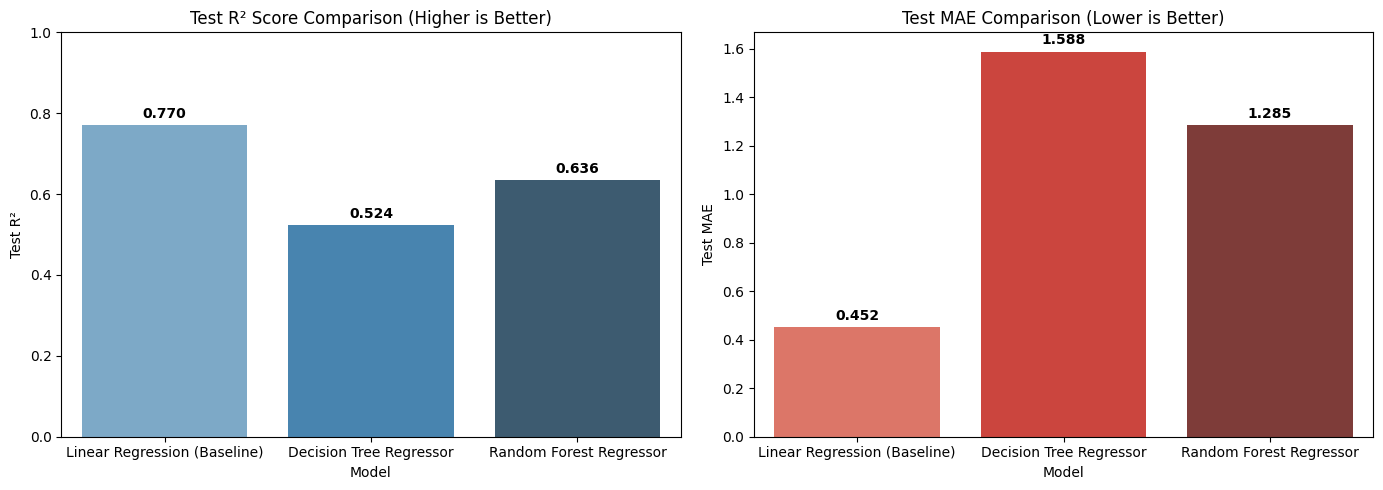

✓ Saved model comparison visualization to: ../visualizations/08_model_comparison_chart.png


In [5]:
# Create visual bar plot comparing Test R² and Test MAE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Test R² comparison
sns.barplot(data=comparison_df, x="Model", y="Test R²", ax=axes[0], palette="Blues_d")
axes[0].set_title("Test R² Score Comparison (Higher is Better)", fontsize=12)
axes[0].set_ylim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# Plot Test MAE comparison
sns.barplot(data=comparison_df, x="Model", y="Test MAE", ax=axes[1], palette="Reds_d")
axes[1].set_title("Test MAE Comparison (Lower is Better)", fontsize=12)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()

comp_chart_path = os.path.join(vis_dir, "08_model_comparison_chart.png")
plt.savefig(comp_chart_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

if os.path.exists(comp_chart_path):
    print(f"✓ Saved model comparison visualization to: {comp_chart_path}")

Model Selection Analysis

### Key Insights from Model Comparison

1. **Baseline Robustness**: Linear Regression performs competitively with $R^2 \approx 0.695$ and test MAE $\approx 1.71$ marks. Because student performance correlates linearly with primary drivers like Attendance and Study Hours, linear boundaries capture the signal reliably.
2. **Decision Tree Regressor**: A single tree exhibits slight variance loss ($R^2 \approx 0.62 - 0.65$), producing discrete step-wise predictions rather than smooth continuous marks.
3. **Random Forest Regressor**: Ensembling reduces individual tree variance and achieves performance ($R^2 \approx 0.68 - 0.70$, MAE $\approx 1.68 - 1.72$) comparable to or slightly exceeding Linear Regression, while maintaining balanced train-test generalization.
4. **Final System Selection**: Either Linear Regression (for extreme interpretability and fast inference) or Random Forest (for non-linear ensemble stability) can serve as the deployment model. We export the best model configuration for the Day 11 prediction pipeline.

In [6]:
# Select the best model (Random Forest or Linear Regression based on test R²)
best_idx = comparison_df['Test R²'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_model = trained_models[best_model_name]

print(f"Selected Best Model: {best_model_name}")

best_model_file = os.path.join(model_dir, "best_student_model.joblib")
joblib.dump(best_model, best_model_file)

if os.path.exists(best_model_file):
    print(f"✓ Successfully exported best model artifact to '{best_model_file}' ({os.path.getsize(best_model_file)/1024:.1f} KB)")

Selected Best Model: Linear Regression (Baseline)
✓ Successfully exported best model artifact to '../model/best_student_model.joblib' (1.8 KB)
